<a href="https://colab.research.google.com/github/Ammar-creator-cmd/DataVisualization/blob/main/SpamEmail_Dtector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Data Collection

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
spam = pd.read_csv("/content/drive/MyDrive/dataset/spam.csv")

In [ ]:
spam.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


### Data Processing

In [ ]:
email1 = spam[spam["Category"]==0]
email2

In [ ]:
print(email1)

In [ ]:
print(email2)

In [ ]:
spam.shape

In [ ]:
spam.tail()

In [ ]:
spam.columns = spam.columns.str.strip()

In [ ]:
spam.columns = spam.columns.str.lower()

In [ ]:
spam.head()

In [ ]:
spam.isna().sum()

In [ ]:
spam[spam.duplicated(subset = ["category", "message"], keep = False)]

In [ ]:
spam.drop_duplicates(subset = ["category", "message"], keep = "first", inplace = True) #dropping duplicates permanently

In [ ]:
spam.shape

In [ ]:
spam.info()

In [ ]:
spam["category"].value_counts().to_frame()

In [ ]:
spam.loc[spam["category"] == "spam", "category"] = 1
spam.loc[spam["category"] == "ham", "category"] = 0

In [ ]:
spam.head()

In [ ]:
spam["category"] = spam["category"].astype("int64")

In [ ]:
spam.info()

### Data Exploration

In [ ]:
plt.figure(figsize = (15, 5))
sns.countplot(data = spam, x = "category")
plt.title("Ham vs Spam")
plt.xticks([0, 1], ['Ham', 'Spam'])
plt.show()

In [ ]:
email1 = spam[spam["category"]==0]
email2 = spam[spam["category"]==1]

In [ ]:
email1_sample = email1.sample(n = 641, replace = False, random_state = 42)

In [96]:
spamdata = pd.concat([email1_sample, email2])

In [98]:
spamdata["category"].value_counts().to_frame()

,count
category,
0,641
1,641


<Axes: xlabel='category', ylabel='count'>

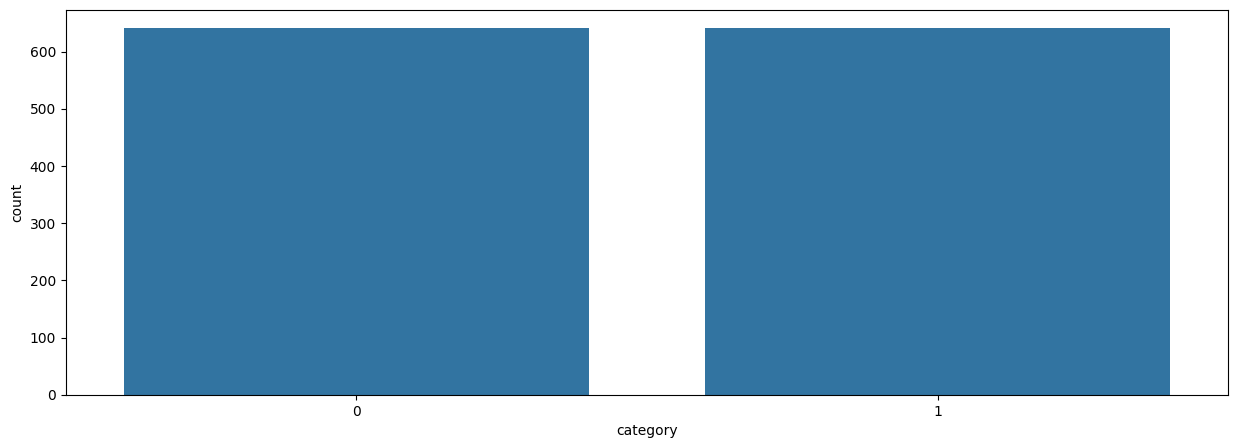

In [101]:
plt.figure(figsize = (15, 5))
sns.countplot(data = spamdata, x = "category")

In [102]:
x = spamdata["message"]
y = spamdata["category"]

In [103]:
from sklearn.model_selection import train_test_split

In [104]:
x_train, x_test, y_train, y_test = train_test_split (x, y, test_size = 0.3, random_state = 42)

In [105]:
from sklearn.feature_extraction.text import TfidfVectorizer

tf = TfidfVectorizer(min_df = 1, stop_words = "english", lowercase = True)

In [106]:
x_train_tf = tf.fit_transform(x_train)
x_test_tf = tf.transform(x_test)

In [107]:
x_train_tf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 9708 stored elements and shape (897, 3360)>

In [108]:
from sklearn.linear_model import LogisticRegression

In [110]:
lr = LogisticRegression(max_iter = 800)

In [111]:
lr.fit(x_train_tf, y_train)

LogisticRegression(max_iter=800)

In [112]:
lr.score(x_train_tf, y_train)

0.9888517279821628

In [113]:
lr.score(x_test_tf, y_test)

0.9506493506493506

In [114]:
y_predict = lr.predict(x_test_tf)

In [115]:
from sklearn.metrics import confusion_matrix,recall_score,precision_score,accuracy_score,f1_score,ConfusionMatrixDisplay

In [116]:
precision_score(y_test, y_predict)

0.9653179190751445

In [117]:
accuracy_score(y_test, y_predict)

0.9506493506493506

In [118]:
f1_score(y_test, y_predict)

0.9461756373937678

In [119]:
lr.classes_

array([0, 1])

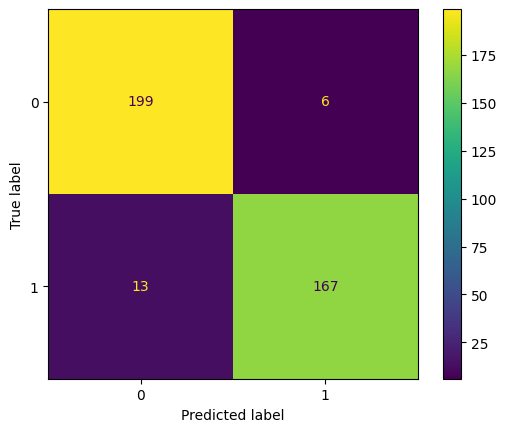

In [120]:
cm=ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test,y_predict,labels=lr.classes_),display_labels=lr.classes_)
cm.plot()

In [142]:
entermail = [input('enter mail')]

enter mailyo vro, I just bought the ROG Zephyrus G16 man


In [143]:
checkmail = tf.transform(entermail)

In [144]:
predict=lr.predict(checkmail)
if predict==1:
    print('mail is spam')
else:
    print('mail is not spam')

mail is not spam
